In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q findspark
import findspark
findspark.init()

In [2]:

from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf

spark = (
    SparkSession.builder
    .appName("pyspark-Validation_Kmean")
    .master("local[*]")
    .config('spark.ui.port', '4050')
    .config("spark.driver.memory", "35g")
    .config("spark.driver.memoryOverhead", "4g")

    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.default.parallelism", "16")

    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")

    .getOrCreate()
)

spark


In [ ]:
# spark.stop()

In [ ]:
!pip install -q ngrok


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 39.9 MB/s eta 0:00:00


In [ ]:
!wget -q https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.tgz
!tar -xzf ngrok-v3-stable-linux-amd64.tgz
!chmod +x ngrok
get_ipython().system_raw('!./ngrok http 4050 &')


In [ ]:
!./ngrok authtoken 372K2OENTZEIyObJBECpiQP0wUR_BgEkQykJerjtRoPQJsoH

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
!nohup ./ngrok http 4050 --log=stdout --log-format=logfmt > ngrok.log 2>&1 &


In [3]:
parquet_path_raw = "/content/drive/MyDrive/bigdata/cic_ddos_raw.parquet"
parquet_path_25 = r"/content/drive/MyDrive/bigdata/cic_ddos_pca_25.parquet"
parquet_path_21 = r"/content/drive/MyDrive/bigdata/cic_ddos_pca_21.parquet"
parquet_path_27 = r"/content/drive/MyDrive/bigdata/cic_ddos_rf_27.parquet"

df_feature_raw = spark.read.parquet(parquet_path_raw).cache()
df_feature_25 = spark.read.parquet(parquet_path_25).cache()
df_feature_21 = spark.read.parquet(parquet_path_21).cache()
df_feature_27 = spark.read.parquet(parquet_path_27).cache()

df_feature_25.printSchema(), df_feature_21.printSchema(), df_feature_27.printSchema(), df_feature_raw.printSchema()

root
 |-- pca_k25: vector (nullable = true)
 |-- label: string (nullable = true)

root
 |-- pca_k21: vector (nullable = true)
 |-- label: string (nullable = true)

root
 |-- label: string (nullable = true)
 |-- rf_27: vector (nullable = true)

root
 |-- features: vector (nullable = true)
 |-- label: string (nullable = true)



(None, None, None, None)

In [4]:
from pyspark.ml.feature import StringIndexer
label_indexer = StringIndexer(
    inputCol="label",
    outputCol="label_index",
    handleInvalid="skip"
)
df_indexed_25 = label_indexer.fit(df_feature_25).transform(df_feature_25)
df_indexed_21 = label_indexer.fit(df_feature_21).transform(df_feature_21)
df_indexed_27 = label_indexer.fit(df_feature_27).transform(df_feature_27)
df_indexed_raw = label_indexer.fit(df_feature_raw).transform(df_feature_raw)


In [5]:
from pyspark.sql.functions import lit

def split_train_test(df_indexed):
  fractions = (
      df_indexed
      .select("label")
      .distinct()
      .withColumn("fraction", lit(0.02))
      .rdd.collectAsMap()
  )

  test_df = df_indexed.sampleBy(
      "label",
      fractions,
      seed=42
  )
  return test_df, df_indexed.subtract(test_df)

test_df_25, train_df_25 = split_train_test(df_indexed_25)
test_df_21, train_df_21 = split_train_test(df_indexed_21)
test_df_27, train_df_27 = split_train_test(df_indexed_27)
test_df_raw, train_df_raw = split_train_test(df_indexed_raw)

In [6]:

from pyspark.ml.clustering import KMeansModel
from pyspark.ml.evaluation import ClusteringEvaluator
import pyspark.sql.functions as F
from sklearn.metrics import normalized_mutual_info_score

kmeans_model_raw_path = r"/content/drive/MyDrive/bigdata/model/kmeans_cic_ddos_2019_raw"
kmeans_model_k21_path = r"/content/drive/MyDrive/bigdata/model/kmeans_cic_ddos_2019_pca_k21"
kmeans_model_k25_path = r"/content/drive/MyDrive/bigdata/model/kmeans_cic_ddos_2019_pca_k25"
kmeans_model_k27_path = r"/content/drive/MyDrive/bigdata/model/kmeans_cic_ddos_2019_rf_k27"



kmeans_model_raw = KMeansModel.load(kmeans_model_raw_path)
kmeans_model_k21 = KMeansModel.load(kmeans_model_k21_path)
kmeans_model_k25 = KMeansModel.load(kmeans_model_k25_path)
kmeans_model_k27 = KMeansModel.load(kmeans_model_k27_path)


In [7]:
df_cluster_raw = kmeans_model_raw.transform(test_df_raw)
df_cluster_k21 = kmeans_model_k21.transform(test_df_21)
df_cluster_k25 = kmeans_model_k25.transform(test_df_25)
df_cluster_k27 = kmeans_model_k27.transform(test_df_27)

# Visualize Kmean

In [16]:
from pyspark.ml.feature import StandardScaler

def normalize(df, feature_col):
    scaler = StandardScaler(
        inputCol=feature_col,
        outputCol=feature_col + "_scaled",
        withMean=True,
        withStd=True
    )
    model = scaler.fit(df)
    return model.transform(df)
df_raw_norm = normalize(df_cluster_raw, "features")
df_k21_norm = normalize(df_cluster_k21, "pca_k21")
df_k25_norm = normalize(df_cluster_k25, "pca_k25")
df_k27_norm = normalize(df_cluster_k27, "rf_27")


In [18]:
from pyspark.ml.feature import PCA

def pca_2d(df, feature_col):
    pca = PCA(k=2, inputCol=feature_col, outputCol="pca2")
    model = pca.fit(df)
    return model.transform(df)
df_raw_2d = pca_2d(df_raw_norm, "features_scaled")
df_k21_2d = pca_2d(df_k21_norm, "pca_k21_scaled")
df_k25_2d = pca_2d(df_k25_norm, "pca_k25_scaled")
df_k27_2d = pca_2d(df_k27_norm, "rf_27_scaled")



In [19]:
pdf_raw  = df_raw_2d.select("pca2", "prediction").toPandas()
pdf_k21  = df_k21_2d.select("pca2", "prediction").toPandas()
pdf_k25  = df_k25_2d.select("pca2", "prediction").toPandas()
pdf_k27  = df_k27_2d.select("pca2", "prediction").toPandas()

def split_xy(pdf):
    pdf["x"] = pdf["pca2"].apply(lambda v: float(v[0]))
    pdf["y"] = pdf["pca2"].apply(lambda v: float(v[1]))
    return pdf

pdf_raw  = split_xy(pdf_raw)
pdf_k21  = split_xy(pdf_k21)
pdf_k25  = split_xy(pdf_k25)
pdf_k27  = split_xy(pdf_k27)


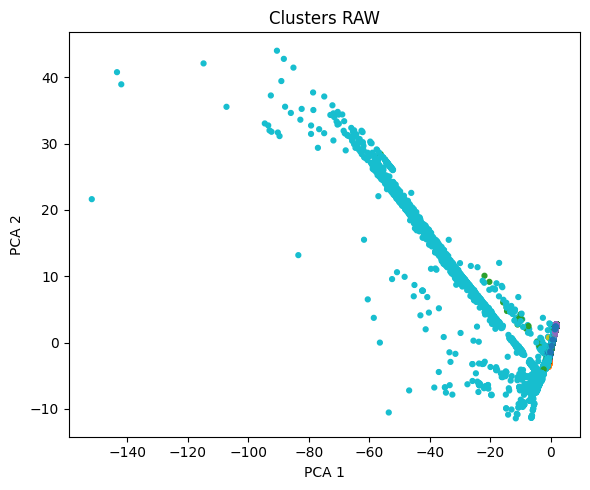

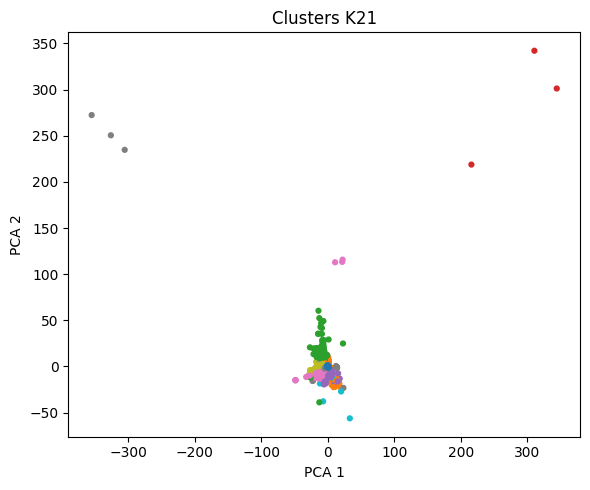

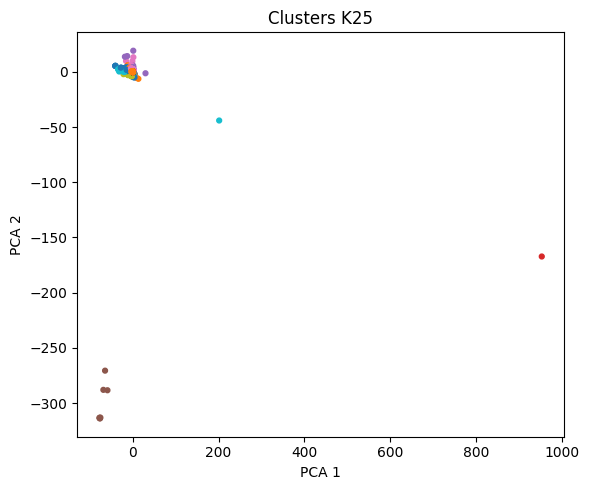

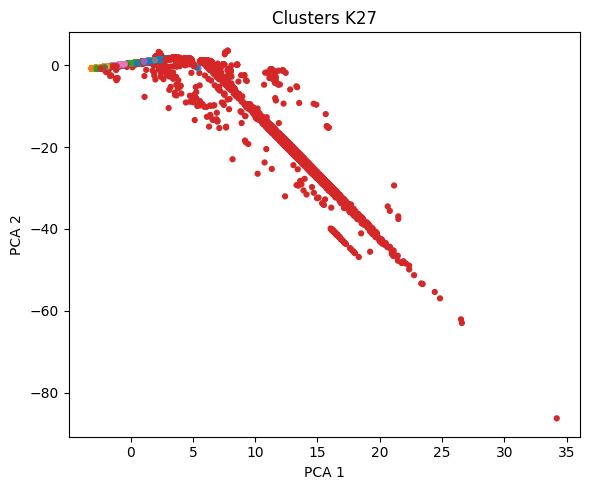

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cluster(pdf, title):
    clusters = sorted(pdf["prediction"].unique())
    plt.figure(figsize=(6,5))

    for c in clusters:
        sub = pdf[pdf["prediction"] == c]
        plt.scatter(sub["x"], sub["y"], s=12, label=f"Cluster {c}")

    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


plot_cluster(pdf_raw, "Clusters RAW (PCA-2)")
plot_cluster(pdf_k21, "Clusters K21 (PCA-2)")
plot_cluster(pdf_k25, "Clusters K25 (PCA-2)")
plot_cluster(pdf_k27, "Clusters K27 (PCA-2)")


# Đánh giá silhousette, purity, nmi

In [8]:
def silhouette(df, feature_col):
    ev = ClusteringEvaluator(featuresCol=feature_col)
    return ev.evaluate(df)

def purity(df, pred_col="prediction", label_col="label_index"):
    tbl = df.groupBy(pred_col, label_col).count()
    maj = tbl.groupBy(pred_col).agg(F.max("count").alias("maj"))
    correct = maj.agg(F.sum("maj")).first()[0]
    total = df.count()
    return correct / total

def nmi(df):
    pdf = df.select("label_index", "prediction").toPandas()
    return normalized_mutual_info_score(pdf["label_index"], pdf["prediction"])

sil_raw = silhouette(df_cluster_raw, "features")
sil_k21 = silhouette(df_cluster_k21, "pca_k21")
sil_k25 = silhouette(df_cluster_k25, "pca_k25")
sil_k27 = silhouette(df_cluster_k27, "rf_27")

pur_raw = purity(df_cluster_raw)
pur_k21 = purity(df_cluster_k21)
pur_k25 = purity(df_cluster_k25)
pur_k27 = purity(df_cluster_k27)

nmi_raw = nmi(df_cluster_raw)
nmi_k21 = nmi(df_cluster_k21)
nmi_k25 = nmi(df_cluster_k25)
nmi_k27 = nmi(df_cluster_k27)

# Visualize

In [9]:
metrics = {
    "RAW":  {"Silhouette": sil_raw,  "Purity": pur_raw,  "NMI": nmi_raw},
    "K21":  {"Silhouette": sil_k21,  "Purity": pur_k21,  "NMI": nmi_k21},
    "K25":  {"Silhouette": sil_k25,  "Purity": pur_k25,  "NMI": nmi_k25},
    "K27":  {"Silhouette": sil_k27,  "Purity": pur_k27,  "NMI": nmi_k27}
}


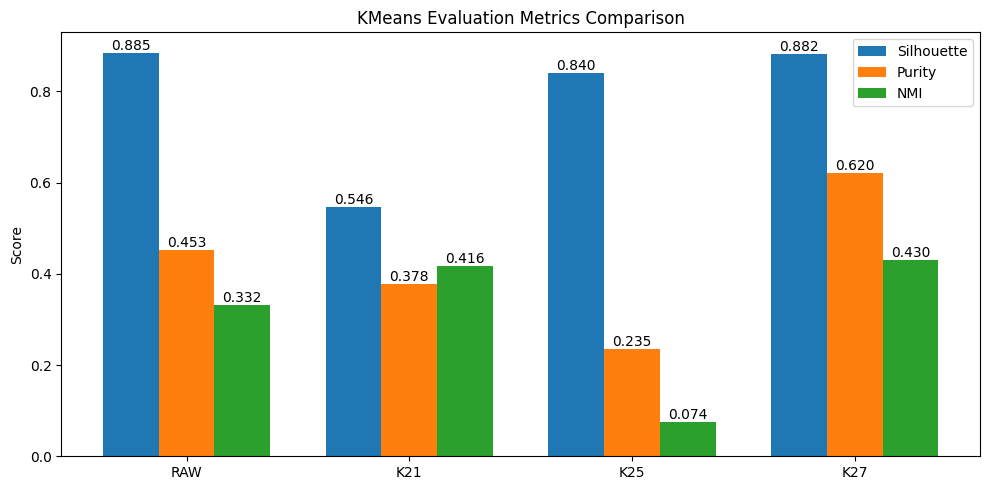

In [11]:
import matplotlib.pyplot as plt
import numpy as np

models = list(metrics.keys())
sil_vals = [metrics[m]["Silhouette"] for m in models]
pur_vals = [metrics[m]["Purity"] for m in models]
nmi_vals = [metrics[m]["NMI"] for m in models]

x = np.arange(len(models))
w = 0.25

plt.figure(figsize=(10,5))

b1 = plt.bar(x - w, sil_vals, width=w, label="Silhouette")
b2 = plt.bar(x,     pur_vals, width=w, label="Purity")
b3 = plt.bar(x + w, nmi_vals, width=w, label="NMI")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("KMeans Evaluation Metrics Comparison")
plt.legend()
plt.tight_layout()

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{h:.3f}",
            ha="center",
            va="bottom"
        )

plt.show()
